In [1]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
import torch
from torch import tensor
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from torchvision.ops import masks_to_boxes
import matplotlib.patches as patches
import json
from pathlib import Path
import matplotlib.patches as patches
import time

In [2]:
fast_rcnn = fasterrcnn_resnet50_fpn_v2(num_classes=2)


In [16]:
# fast_rcnn.eval()
test_tensor = torch.rand(1, 1, 1000, 1000)

test_label = [
    {
        'boxes': tensor([[0, 0, 10, 10]]),
        'labels': tensor([1], dtype=torch.int64),
    }
]

fast_rcnn(test_tensor, test_label)
# fast_rcnn.eval()
# fast_rcnn(test_tensor, test_label)

[{'boxes': tensor([[616.6262, 418.8234, 671.1959, 444.7007],
          [721.8869, 783.8582, 777.8323, 810.7048],
          [569.4307, 258.9932, 669.7902, 312.0069],
          [891.9919, 599.0909, 946.1527, 625.7126],
          [882.4647, 564.4230, 937.0378, 591.0465],
          [647.3821, 189.5133, 702.2081, 215.4876],
          [332.2534, 128.9372, 389.1520, 155.3154],
          [881.9774, 579.3970, 937.0465, 605.7562],
          [388.3604, 368.5782, 493.7136, 421.8948],
          [409.6397, 478.9707, 513.3934, 532.0370],
          [586.1982, 276.9740, 692.0396, 330.2936],
          [620.4785, 654.2860, 677.2218, 679.4880],
          [282.1121, 769.2583, 338.1212, 795.1521],
          [127.0607, 298.5704, 182.0266, 325.9914],
          [721.2605, 769.2758, 777.9437, 795.7266],
          [411.4241, 499.2891, 516.8046, 551.6526],
          [320.2622,  77.4067, 426.1352, 131.6608],
          [903.3239, 415.0467, 958.2493, 440.2015],
          [621.9453, 349.4422, 677.3198, 375.2585],
   

In [4]:
def get_bounding_boxes(segmented_matrix):
    labels = np.unique(segmented_matrix)
    labels = labels[labels != -1]  # Remove background label (-1)

    boxes = []
    labels_list = []

    for label in labels:
        coords = np.argwhere(segmented_matrix == label)
        if coords.size == 0:
            continue

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        boxes.append([x_min, y_min, x_max, y_max])
        labels_list.append(label + 1)  # Assuming labels start from 1

    return boxes, labels_list

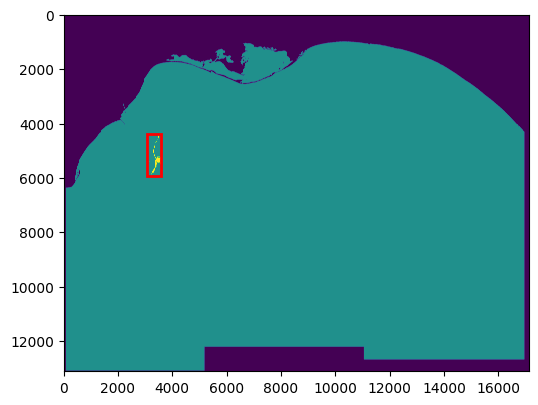

[{'boxes': tensor([[3070.2778, 4376.9116, 3594.8936, 5924.8101]]), 'labels': tensor([1])}]


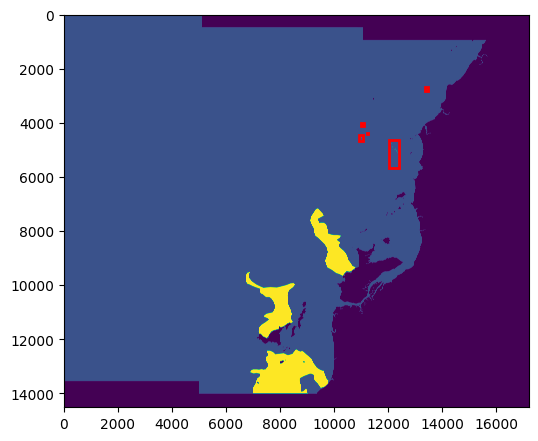

[{'boxes': tensor([[12022.2441,  4639.1577, 12411.0000,  5652.0000],
        [10929.3779,  4434.6631, 11068.0000,  4681.0000],
        [11223.0000,  4379.0000, 11244.0000,  4413.0000],
        [10999.0000,  3997.0000, 11087.0000,  4117.0000],
        [13370.0000,  2673.0000, 13469.0000,  2806.0000]]), 'labels': tensor([1, 1, 1, 1, 1])}]


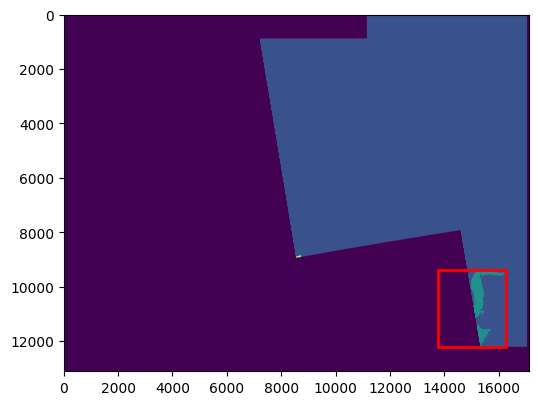

[{'boxes': tensor([[13776.5957,  9395.9619, 16246.8457, 12219.8223]]), 'labels': tensor([1])}]


KeyboardInterrupt: 

In [20]:

# Load label mapping from label_order.json
def load_label_mapping(label_order_path):
    with open(label_order_path, 'r') as file:
        label_order = json.load(file)
    label_name_to_num = label_order["label_name_to_num"]
    label_aliases = label_order["label_aliases"]
    return label_name_to_num, label_aliases

# Convert LabelMe annotations to bounding boxes
def labelme_to_bboxes(labelme_json, label_name_to_num, label_aliases, target_label="oil"):
    with open(labelme_json, 'r') as file:
        data = json.load(file)

    boxes = []
    labels_list = []

    for shape in data['shapes']:
        label = shape['label']
        if label in label_aliases[target_label]:
            points = shape['points']
            x_coords, y_coords = zip(*points)
            x_min, x_max = min(x_coords), max(x_coords)
            y_min, y_max = min(y_coords), max(y_coords)
            boxes.append([x_min, y_min, x_max, y_max])
            labels_list.append(label_name_to_num[target_label])

    return boxes, labels_list

# Check if two boxes overlap
def boxes_overlap(box1, box2, threshold=100):
    x_min1, y_min1, x_max1, y_max1 = box1
    x_min2, y_min2, x_max2, y_max2 = box2
    
    x_min2 -= threshold
    y_min2 -= threshold
    x_max2 += threshold
    y_max2 += threshold
    
    
    return not (x_max1 < x_min2 or x_max2 < x_min1 or y_max1 < y_min2 or y_max2 < y_min1)

# Merge two boxes
def merge_boxes(box1, box2):
    x_min1, y_min1, x_max1, y_max1 = box1
    x_min2, y_min2, x_max2, y_max2 = box2
    
    x_min = min(x_min1, x_min2)
    y_min = min(y_min1, y_min2)
    x_max = max(x_max1, x_max2)
    y_max = max(y_max1, y_max2)
    
    return [x_min, y_min, x_max, y_max]

# Unify overlapping boxes
def unify_boxes(boxes):
    unified_boxes = []
    merged = [False] * len(boxes)
    
    for i, box1 in enumerate(boxes):
        if merged[i]:
            continue
        
        for j, box2 in enumerate(boxes):
            if i != j and boxes_overlap(box1, box2):
                box1 = merge_boxes(box1, box2)
                merged[j] = True
        
        unified_boxes.append(box1)
    
    return unified_boxes

# image_name = 'F794'
for path in Path('/mnt/camobi_3/new_data/labels_json').glob('*.json'):
    image_name = path.stem
    label_order_path = '/mnt/camobi_3/new_data/label_order.json'
    label_name_to_num, label_aliases = load_label_mapping(label_order_path)
    
    # Example usage
    labelme_json_path = f'/mnt/camobi_3/new_data/labels_json/{image_name}.json'
    boxes, labels_list = labelme_to_bboxes(labelme_json_path, label_name_to_num, label_aliases, target_label="oil")
    
    unified_boxes = None
    while not unified_boxes == unify_boxes(boxes):
        unified_boxes = unify_boxes(boxes)
        boxes = unified_boxes
    
    
    test_label = [
        {
            'boxes': torch.tensor(unified_boxes, dtype=torch.float32),
            'labels': torch.tensor([label_name_to_num["oil"]] * len(unified_boxes), dtype=torch.int64),
        }
    ]
    
    nc_image = xr.open_dataset(f'/mnt/camobi_process/test_dataset/{image_name}.nc')
    label_img = nc_image.label.values

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(label_img, cmap='viridis')
    
    # Add bounding boxes
    for box in test_label[0]['boxes']:
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    
    plt.show()
    print(test_label)
    # break

In [19]:
test_label

rand_crop_corner = test_label[0]['boxes']
label_img.shape
rand_crop_corner


tensor([[3070.2778, 4376.9116, 3594.8936, 5924.8101]])

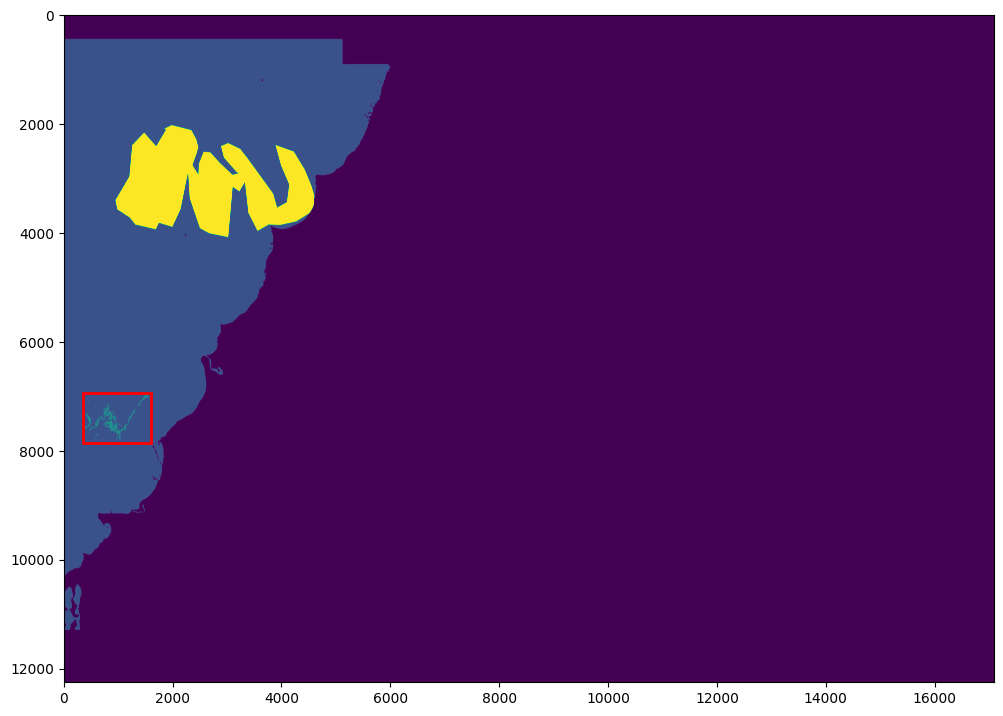

In [191]:
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(label_img, cmap='viridis')

# Add bounding boxes
for box in test_label[0]['boxes']:
    x_min, y_min, x_max, y_max = box
    rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

plt.show()